# Phase 3: Damage Adaptation with Joint-Aware Visual Control

This notebook evaluates NeuroKin-3D's ability to adapt to hardware failures (encoder slip) through visual feedback combined with joint angle estimation.

In [1]:
import os
import sys
import time
import random
import importlib.util
import numpy as np
import matplotlib.pyplot as plt

def ensure_package(pkg):
    if importlib.util.find_spec(pkg) is None:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', pkg])

for pkg in ['pybullet', 'opencv-python', 'torch']:
    ensure_package(pkg)

import pybullet as p
import pybullet_data
import cv2
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cpu


In [2]:
def build_camera_matrices(camera_pos, target_pos, up_vec, fov, aspect, near, far):
    view = p.computeViewMatrix(cameraEyePosition=camera_pos, cameraTargetPosition=target_pos, cameraUpVector=up_vec)
    proj = p.computeProjectionMatrixFOV(fov=fov, aspect=aspect, nearVal=near, farVal=far)
    return view, proj


def preprocess_image(rgb, threshold=240):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return (gray < threshold).astype(np.uint8) * 255


class DualCameraEnv:
    def __init__(self, urdf_path, width=100, height=100, cam_dist=1.0, fov=42, near=0.1, far=100.0, sim_steps=10):
        self.urdf_path = urdf_path
        self.width = width
        self.height = height
        self.aspect = width / float(height)
        self.fov = fov
        self.near = near
        self.far = far
        self.sim_steps = sim_steps
        self.num_motor = 4
        self.max_angle_rad = np.pi / 2

        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())

        cam1_cfg = {'pos': [cam_dist, 0, 0], 'target': [0, 0, 0], 'up': [0, 0, 1]}
        cam2_cfg = {'pos': [0, cam_dist, 0], 'target': [0, 0, 0], 'up': [0, 0, 1]}
        self.cam1_view, self.cam1_proj = build_camera_matrices(cam1_cfg['pos'], cam1_cfg['target'], cam1_cfg['up'], self.fov, self.aspect, self.near, self.far)
        self.cam2_view, self.cam2_proj = build_camera_matrices(cam2_cfg['pos'], cam2_cfg['target'], cam2_cfg['up'], self.fov, self.aspect, self.near, self.far)
        self.reset()

    def reset(self):
        p.resetSimulation()
        p.setGravity(0, 0, -9.8)
        plane_visual_shape_id = p.createVisualShape(shapeType=p.GEOM_PLANE, rgbaColor=[1, 1, 1, 1], planeNormal=[0, 0, 1])
        p.createMultiBody(baseMass=0, baseVisualShapeIndex=plane_visual_shape_id, basePosition=[0, 0, -0.109])
        self.robot_id = p.loadURDF(self.urdf_path, [0, 0, -0.108], p.getQuaternionFromEuler([0, 0, -np.pi / 2]), useFixedBase=1)
        for i in range(p.getNumJoints(self.robot_id)):
            p.resetJointState(self.robot_id, i, 0)
        self.ee_link_index = p.getNumJoints(self.robot_id) - 1

    def _capture(self, view, proj):
        img_arr = p.getCameraImage(self.width, self.height, view, proj, renderer=p.ER_TINY_RENDERER, shadow=0)
        rgb = np.reshape(img_arr[2], (self.height, self.width, 4))[:, :, :3]
        return rgb.astype(np.uint8)

    def capture_views(self):
        return self._capture(self.cam1_view, self.cam1_proj), self._capture(self.cam2_view, self.cam2_proj)

    def get_gt_ee(self):
        ee_pos = p.getLinkState(self.robot_id, self.ee_link_index, computeForwardKinematics=True)[0]
        return np.array(ee_pos, dtype=np.float32)

    def get_joint_angles(self):
        return np.array([p.getJointState(self.robot_id, i)[0] for i in range(self.num_motor)], dtype=np.float32)

    def set_joint_positions(self, joint_targets):
        for i in range(self.num_motor):
            p.setJointMotorControl2(bodyUniqueId=self.robot_id, jointIndex=i, controlMode=p.POSITION_CONTROL, targetPosition=joint_targets[i], force=100)

    def step_sim(self):
        for _ in range(self.sim_steps):
            p.stepSimulation()

    def close(self):
        p.disconnect()


class PositionalEncoding2D(nn.Module):
    def __init__(self, height, width):
        super().__init__()
        y_coords = torch.linspace(-1, 1, steps=height)
        x_coords = torch.linspace(-1, 1, steps=width)
        grid_y, grid_x = torch.meshgrid(y_coords, x_coords, indexing='ij')
        self.register_buffer('grid', torch.stack([grid_x, grid_y], dim=0).unsqueeze(0))

    def forward(self, x):
        return torch.cat([x, self.grid.expand(x.size(0), -1, -1, -1)], dim=1)


class SpatialConvStream(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

    def forward(self, x):
        return self.net(x)


class NeuroKin3D(nn.Module):
    def __init__(self, image_h=100, image_w=100):
        super().__init__()
        self.pos_enc = PositionalEncoding2D(height=image_h, width=image_w)
        self.cam1_stream = SpatialConvStream(in_channels=3)
        self.cam2_stream = SpatialConvStream(in_channels=3)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, image_h, image_w)
            feat_dim = int(np.prod(self.cam1_stream(dummy).shape[1:]))
        self.virtual_frame_proj = nn.Sequential(nn.Linear(feat_dim * 2, 512), nn.LayerNorm(512), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 7))

    def forward(self, cam1, cam2):
        cam1_spatial = self.pos_enc(cam1)
        cam2_spatial = self.pos_enc(cam2)
        f1 = self.cam1_stream(cam1_spatial).flatten(1)
        f2 = self.cam2_stream(cam2_spatial).flatten(1)
        return self.head(self.virtual_frame_proj(torch.cat([f1, f2], dim=1)))

In [3]:
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

ROOT_CANDIDATES = [
    '/content/drive/MyDrive/robot_self_modelling',
    '/content/robot_self_modelling',
    os.path.abspath('.'),
]

ROOT_DIR = next((p for p in ROOT_CANDIDATES if os.path.exists(p)), os.path.abspath('.'))
URDF_PATH = os.path.join(ROOT_DIR, 'RobotArmURDF', '4dof_1st', 'urdf', '4dof_1st.urdf')
MODEL_PATH = os.path.join(ROOT_DIR, 'models', 'neurokin_3d_best.pth')

if not os.path.exists(URDF_PATH):
    raise FileNotFoundError(f'URDF not found: {URDF_PATH}')

OUTPUT_DIR = os.path.join(ROOT_DIR, 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(OUTPUT_DIR, 'neurokin_3d_best.pth')

model = NeuroKin3D().to(device)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'Model not found: {MODEL_PATH}')

checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=True)
model.eval()

env = DualCameraEnv(URDF_PATH, width=100, height=100, cam_dist=1.0, sim_steps=50)

JOINT_LIMITS = []
for i in range(env.num_motor):
    info = p.getJointInfo(env.robot_id, i)
    lower, upper = info[8], info[9]
    if lower >= upper:
        lower, upper = -env.max_angle_rad, env.max_angle_rad
    JOINT_LIMITS.append((lower, upper))
JOINT_LIMITS = np.array(JOINT_LIMITS, dtype=np.float32)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def estimate_ee_xyz(rgb1, rgb2, model, device):
    mask1 = preprocess_image(rgb1)
    mask2 = preprocess_image(rgb2)
    cam1 = torch.from_numpy(mask1.astype(np.float32) / 255.0)[None, None, ...].to(device)
    cam2 = torch.from_numpy(mask2.astype(np.float32) / 255.0)[None, None, ...].to(device)
    with torch.no_grad():
        raw_pred = model(cam1, cam2).cpu().numpy().squeeze(0)
    return raw_pred[:3], raw_pred[3:7] * 90.0


def sample_reachable_target(root_dir):
    test_path = os.path.join(root_dir, 'data', 'sim_data_multi_view', 'mv_robo1_test.npz')
    if os.path.exists(test_path):
        data = np.load(test_path)
        ee_xyz = data['ee_xyz']
        return ee_xyz[np.random.randint(len(ee_xyz))]
    return np.array([0.15, 0.0, 0.15], dtype=np.float32)


def run_thesis_benchmarks(
    env, model, device, target_xyz, joint_limits,
    mode="baseline",
    num_steps=200, step_gain=0.25, step_gain_i=0.06, max_step=0.01
):
    gt_log = []
    err_log = []
    est_log = []
    est_joints_log = []
    gt_joints_log = []

    env.reset()

    current_commanded_xyz = env.get_gt_ee().copy()
    prev_visual_error = np.zeros(3, dtype=np.float32)

    lower = joint_limits[:, 0]
    upper = joint_limits[:, 1]
    ranges = upper - lower
    joint_damping = [0.01] * env.num_motor

    for _ in range(num_steps):
        gt_xyz = env.get_gt_ee()
        gt_joints_deg = env.get_joint_angles() * 180.0 / np.pi
        gt_log.append(gt_xyz)
        gt_joints_log.append(gt_joints_deg)
        err_log.append(np.linalg.norm(target_xyz - gt_xyz))

        if mode in ["baseline", "triumph"]:
            rgb1, rgb2 = env.capture_views()
            est_xyz, est_joints_deg = estimate_ee_xyz(rgb1, rgb2, model, device)
            est_log.append(est_xyz)
            est_joints_log.append(est_joints_deg)
        elif mode == "failure":
            est_xyz = current_commanded_xyz.copy()
            est_joints_deg = np.zeros(4)
            est_log.append(est_xyz)
            est_joints_log.append(est_joints_deg)

        visual_error = target_xyz - est_xyz
        delta = step_gain * (visual_error - prev_visual_error) + step_gain_i * visual_error

        if max_step is not None:
            delta = np.clip(delta, -max_step, max_step)

        current_commanded_xyz = current_commanded_xyz + delta

        rest = np.deg2rad(est_joints_deg)
        joint_targets = p.calculateInverseKinematics(
            env.robot_id,
            env.ee_link_index,
            current_commanded_xyz,
            lowerLimits=lower.tolist(),
            upperLimits=upper.tolist(),
            jointRanges=ranges.tolist(),
            restPoses=rest.tolist(),
            jointDamping=joint_damping,
            residualThreshold=1e-4,
            maxNumIterations=100,
        )

        joint_targets_clipped = np.clip(np.array(joint_targets[:env.num_motor]), lower, upper)

        if mode in ["failure", "triumph"]:
            joint_targets_clipped[1] = np.clip(joint_targets_clipped[1] + 0.3, lower[1], upper[1])

        env.set_joint_positions(joint_targets_clipped)
        env.step_sim()
        prev_visual_error = visual_error.copy()

    return np.array(gt_log), np.array(est_log), np.array(err_log), np.array(est_joints_log), np.array(gt_joints_log)

Running Baseline (Healthy Arm, Visual Control)...
Running Failure (Damaged Arm, Blind IK)...
Running Triumph (Damaged Arm, NeuroKin3D Visual Control)...


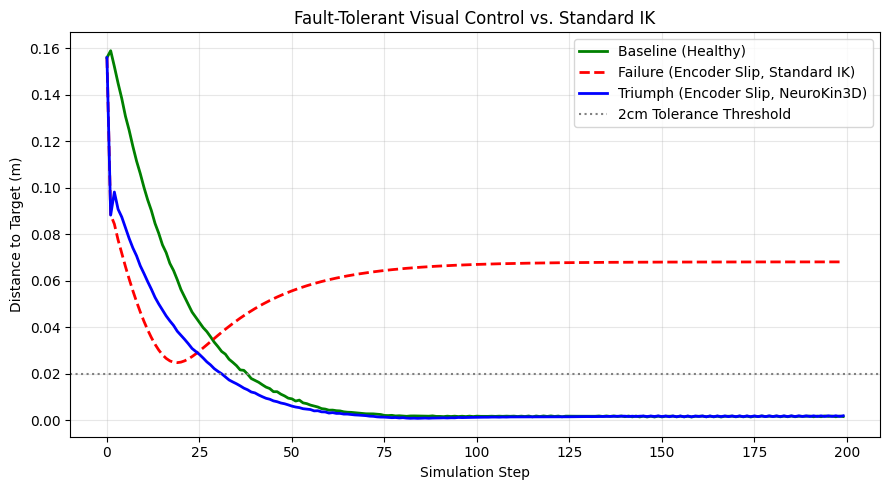

Final Error - Baseline: 0.0016 m
Final Error - Failure:  0.0681 m
Final Error - Triumph:  0.0019 m


In [5]:
target_xyz = sample_reachable_target(ROOT_DIR)

print("Running Baseline (Healthy Arm, Visual Control)...")
gt_baseline, est_baseline, err_baseline, est_j_baseline, gt_j_baseline = run_thesis_benchmarks(env, model, device, target_xyz, JOINT_LIMITS, mode="baseline", num_steps=200)

print("Running Failure (Damaged Arm, Blind IK)...")
gt_failure, est_failure, err_failure, est_j_failure, gt_j_failure = run_thesis_benchmarks(env, model, device, target_xyz, JOINT_LIMITS, mode="failure", num_steps=200)

print("Running Triumph (Damaged Arm, NeuroKin3D Visual Control)...")
gt_triumph, est_triumph, err_triumph, est_j_triumph, gt_j_triumph = run_thesis_benchmarks(env, model, device, target_xyz, JOINT_LIMITS, mode="triumph", num_steps=200)

plt.figure(figsize=(9, 5))
plt.plot(err_baseline, label="Baseline (Healthy)", color='green', linewidth=2)
plt.plot(err_failure, label="Failure (Encoder Slip, Standard IK)", color='red', linestyle='--', linewidth=2)
plt.plot(err_triumph, label="Triumph (Encoder Slip, NeuroKin3D)", color='blue', linewidth=2)

plt.axhline(y=0.02, color='gray', linestyle=':', label="2cm Tolerance Threshold")
plt.xlabel('Simulation Step')
plt.ylabel('Distance to Target (m)')
plt.title('Fault-Tolerant Visual Control vs. Standard IK')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Error - Baseline: {err_baseline[-1]:.4f} m")
print(f"Final Error - Failure:  {err_failure[-1]:.4f} m")
print(f"Final Error - Triumph:  {err_triumph[-1]:.4f} m")

In [6]:
print('\n--- Analysis of NeuroKin3D Estimation Error (Triumph Scenario) ---')

# Calculate the error between estimated and ground truth end-effector positions for the triumph run
estimation_error_triumph = np.linalg.norm(est_triumph - gt_triumph, axis=1)

print(f'NeuroKin3D Estimation Error (Triumph) | mean: {estimation_error_triumph.mean():.4f} m | median: {np.median(estimation_error_triumph):.4f} m | max: {estimation_error_triumph.max():.4f} m')

print('\nGT range per axis (Triumph):')
print('  min:', np.round(gt_triumph.min(axis=0), 4), 'm')
print('  max:', np.round(gt_triumph.max(axis=0), 4), 'm')

print('\nEST range per axis (Triumph):')
print('  min:', np.round(est_triumph.min(axis=0), 4), 'm')
print('  max:', np.round(est_triumph.max(axis=0), 4), 'm')


--- Analysis of NeuroKin3D Estimation Error (Triumph Scenario) ---
NeuroKin3D Estimation Error (Triumph) | mean: 0.0028 m | median: 0.0023 m | max: 0.0099 m

GT range per axis (Triumph):
  min: [0.0813 0.0005 0.1438] m
  max: [0.2036 0.0406 0.2345] m

EST range per axis (Triumph):
  min: [0.0811 0.0008 0.1427] m
  max: [0.2019 0.0396 0.2352] m
